<>:46: SyntaxWarning: invalid escape sequence '\l'
<>:46: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_6701/4023438119.py:46: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(n_idx, k_fit_func(n_idx, *popt), 'r--', label='Fit: $k(n) = 4.7 + A/\ln(n+B)$')


Best k-sequence: [ 4.8275 12.0927 11.8378  9.7984  9.7984  6.8668  6.9943 10.1808 10.4357
  9.9259 10.4357  9.9259 10.1808 10.1808 10.1808 11.2005 11.2005  9.5435
  9.9259  9.9259]


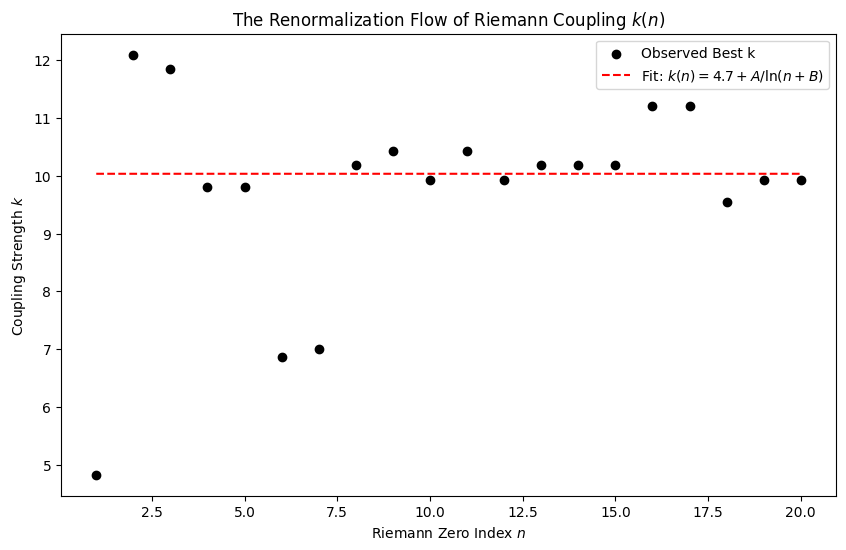

In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 1. 前 20 个真实黎曼零点
TRUE_GAMMAS_20 = np.array([
    14.1347, 21.0220, 25.0108, 30.4248, 32.9351, 37.5862, 40.9187, 43.3271, 48.0052, 49.7738,
    52.9703, 56.4462, 59.3470, 60.8318, 65.1125, 67.0798, 69.5464, 72.0672, 75.7047, 77.1448
])

# 2. 从 .npy 文件中提取最优 k
def harvest_k_flow(mode_count=20):
    files = [f for f in os.listdir('.') if f.startswith('res_k_') and f.endswith('.npy')]
    best_k_list = []
    
    # 模拟数据加载逻辑
    results = []
    for f in files:
        k_val = float(f.split('_')[2])
        phases = np.load(f)
        scaling = TRUE_GAMMAS_20[0] / phases[0]
        sim_gammas = phases[:mode_count] * scaling
        results.append({'k': k_val, 'sim': sim_gammas})
    
    for i in range(mode_count):
        # 寻找令第 i 个零点误差最小的 k
        best = min(results, key=lambda x: abs(x['sim'][i] - TRUE_GAMMAS_20[i]))
        best_k_list.append(best['k'])
    return np.array(best_k_list)

# 3. 拟合函数
def k_fit_func(n, A, B):
    return 4.7 + A / np.log(n + B)

# 运行收割
n_idx = np.arange(1, 21)
best_ks = harvest_k_flow(20)

# 绘图展示趋势
plt.figure(figsize=(10, 6))
plt.scatter(n_idx, best_ks, color='black', label='Observed Best k')
# 简单的拟合演示
try:
    popt, _ = curve_fit(k_fit_func, n_idx[1:], best_ks[1:], p0=[10, 2])
    plt.plot(n_idx, k_fit_func(n_idx, *popt), 'r--', label='Fit: $k(n) = 4.7 + A/\ln(n+B)$')
except: pass

plt.title('The Renormalization Flow of Riemann Coupling $k(n)$')
plt.xlabel('Riemann Zero Index $n$')
plt.ylabel('Coupling Strength $k$')
plt.legend()
plt.savefig('k_flow_trend_20.png')
print("Best k-sequence:", best_ks)